In [ ]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

c = 299792458.0
G = 6.67430e-11
MSUN = 1.98847e30
YR = 365.25 * 24 * 3600.0

rng = np.random.default_rng(0)

n_pulsars = 3
theta_p = np.array([np.pi/2, np.pi/2, 0.0])
phi_p   = np.array([0.0, np.pi/2, 0.0])

LY = 9.4607e15
Lp = rng.uniform(500 * LY, 3000 * LY, size=n_pulsars)

t = np.linspace(0, 15 * YR, 1000) #15 years of observations 1000 time samples

true_theta = 0.05 #theta and phi that I generated I pretended to forget
print('True theta in degrees:',true_theta*(180/np.pi))
true_phi = 0.1
print('True phi in degrees:',true_phi*(180/np.pi))

fixed_gw = (
    0.79,     # iota
    0.05,     # psi
    1.20,     # phi0
    5e8,      # Mc_solar
    8e-7,     # f_gw
    8e23    # D
)
iota, psi, phi0, Mc_solar, f_gw, D = fixed_gw

true_params = (true_theta, true_phi, *fixed_gw)

def _antenna(theta, phi, theta_p, phi_p):
    """Return (F+, Fx) using a consistent denominator."""
    m  = np.array([np.sin(phi), -np.cos(phi), 0.0])
    n  = np.array([np.cos(theta)*np.cos(phi), np.cos(theta)*np.sin(phi), -np.sin(theta)])
    p  = np.array([np.sin(theta_p)*np.cos(phi_p), np.sin(theta_p)*np.sin(phi_p), np.cos(theta_p)])
    om = np.array([np.sin(theta)*np.cos(phi),  np.sin(theta)*np.sin(phi),  np.cos(theta)])
    mp, np_ = np.dot(m, p), np.dot(n, p)
    denom = 1.0 + np.dot(om, p)
    if abs(denom) < 1e-12:
        return np.nan, np.nan          # pulsar is exactly behind the GW source
    return 0.5*(mp**2 - np_**2)/denom, (mp*np_)/denom

def F_plus(theta, phi, theta_p, phi_p):
    return _antenna(theta, phi, theta_p, phi_p)[0]

def F_cross(theta, phi, theta_p, phi_p):
    return _antenna(theta, phi, theta_p, phi_p)[1]

def tau(theta, phi, theta_p, phi_p, Lp):
    return (Lp / c) * (1 + (np.sin(theta) * np.sin(theta_p) * np.cos(phi - phi_p)+ np.cos(theta) * np.cos(theta_p))) #1- or 1+

def amplitude(Mc_solar, f_gw, D):
    Mc = Mc_solar * MSUN
    return (4 / D) * (G * Mc / c**2)**(5/3) * (np.pi * f_gw/c)**(2/3) #/c?

def h_plus(t, h0, f_gw, iota, psi, phi0):
    a_plus = 0.5*(1 + np.cos(iota)**2)
    Phi = 2*np.pi*f_gw*t + 2*phi0
    # psi rotates the polarisation basis; it belongs in the antenna pattern,
    # not baked into the carrier phase
    return h0 * a_plus * (np.cos(Phi)*np.cos(2*psi) - np.sin(Phi)*np.sin(2*psi))

def h_cross(t, h0, f_gw, iota, psi, phi0):
    a_cross = np.cos(iota)
    Phi = 2*np.pi*f_gw*t + 2*phi0
    return h0 * a_cross * (np.sin(Phi)*np.cos(2*psi) + np.cos(Phi)*np.sin(2*psi))

def redshift_pulsar(t, theta, phi, theta_p, phi_p, Lp,
                    iota, psi, phi0, Mc_solar, f_gw, D,
                    use_pulsar_term=True):
    Fp = F_plus(theta, phi, theta_p, phi_p)
    Fx = F_cross(theta, phi, theta_p, phi_p)
    h0 = amplitude(Mc_solar, f_gw, D)

    zE = Fp*h_plus(t, h0, f_gw, iota, psi, phi0) + Fx*h_cross(t, h0, f_gw, iota, psi, phi0)
    if not use_pulsar_term:
        return zE

    delay = tau(theta, phi, theta_p, phi_p, Lp)
    zP = Fp*h_plus(t-delay, h0, f_gw, iota, psi, phi0) + Fx*h_cross(t-delay, h0, f_gw, iota, psi, phi0)
    return zE - zP

def rp(t, theta, phi, theta_p, phi_p, Lp,
       iota, psi, phi0, Mc_solar, f_gw, D,
       use_pulsar_term=True):          # Converts redshift into timing residual.

    z = redshift_pulsar(
        t, theta, phi,
        theta_p, phi_p,
        Lp, iota, psi, phi0,
        Mc_solar, f_gw, D,
        use_pulsar_term=use_pulsar_term
    )
    dt = np.diff(t)
    integrand = 0.5*(z[:-1] + z[1:]) * dt
    return np.concatenate([[0.0], np.cumsum(integrand)])

    #r = np.array([np.trapezoid(z[:i], t[:i]) if i > 1 else 0.0for i in range(len(t))])
    #return r


def simulate_pta(t, theta_p, phi_p, Lp, params, use_pulsar_term=True):
    """
    Simulate PTA timing residuals.
    use_pulsar_term=False : Earth term only (matches analytic approximation)
    use_pulsar_term=True  : Full signal (Earth + pulsar term)
    """
    theta, phi, iota, psi, phi0, Mc_solar, f_gw, D = params

    out = []
    for tp, pp, L in zip(theta_p, phi_p, Lp):
        out.append(rp(t, theta, phi, tp, pp, L,
                      iota, psi, phi0, Mc_solar, f_gw, D,
                      use_pulsar_term=use_pulsar_term))
    return np.array(out)



True theta in degrees: 2.8647889756541165
True phi in degrees: 5.729577951308233


In [ ]:
def analytical_theta_phi_from_residuals(t, residuals, iota, phi0, Mc_solar, f_gw, D):
    """
    residuals shape = (3, obersvation time)
    theta = sqrt( -4*w*r3 / (a_+ * A * sin(Phi)) )
    phi   = -atan2(r2, r1) + asin((r1+r2)/(theta*sqrt(r1^2+r2^2)))
    """
    r1, r2, r3 = residuals

    w = 2.0 * np.pi * f_gw
    a_plus = 0.5 * (1.0 + np.cos(iota)**2)
    Mc = Mc_solar * MSUN
    A = (4.0 / D) * ((G * Mc / c**2)**(5.0 / 3.0)) * ((np.pi * f_gw / c)**(2.0 / 3.0))
    Phi = w * t + 2.0 * phi0

    theta_analytic = np.full_like(t, np.nan, dtype=float) #Empty putput arrays
    phi_analytic = np.full_like(t, np.nan, dtype=float)

    # Theta
    denom_theta = a_plus * A * np.sin(Phi)
    mask_theta = np.abs(denom_theta) > 1e-30 # keeps only points where the denominator is safely away from zero

    theta_arg = np.full_like(t, np.nan, dtype=float)
    theta_arg[mask_theta] = -4.0 * w * r3[mask_theta] / denom_theta[mask_theta]

    valid_theta = mask_theta & (theta_arg >= 0.0) # Inside the sqrt of theta to be real
    theta_analytic[valid_theta] = np.sqrt(theta_arg[valid_theta])

    # Phi
    denom_phi = theta_analytic * np.sqrt(r1**2 + r2**2)
    mask_phi = np.isfinite(theta_analytic) & (denom_phi > 1e-30) # So that denominator is not 0

    asin_arg = np.full_like(t, np.nan, dtype=float)
    asin_arg[mask_phi] = (r1[mask_phi] + r2[mask_phi]) / denom_phi[mask_phi]

    good_asin = mask_phi & (asin_arg >= -1.0) & (asin_arg <= 1.0) #Arcsin only exists from -1 to 1
    phi_analytic[good_asin] = (-np.arctan2(r2[good_asin], r1[good_asin])+ np.arcsin(asin_arg[good_asin]))

    return theta_analytic, phi_analytic



In [ ]:
residuals = simulate_pta(t, theta_p, phi_p, Lp, true_params, use_pulsar_term=False)

rng = np.random.default_rng(0)

signal_scale = np.std(residuals, axis=1)  # per-pulsar signal amplitude
sigma = 0.1 * signal_scale.min()   # e.g. 10% of the smallest signal size
noise = rng.normal(0.0, sigma, size=residuals.shape)
noisy_residuals = residuals + noise

theta_analytic, phi_analytic = analytical_theta_phi_from_residuals(t, noisy_residuals, iota, phi0, Mc_solar, f_gw, D)

theta_med = np.nanmedian(theta_analytic)
phi_med   = np.nanmedian(phi_analytic)
theta_mean = np.nanmean(theta_analytic)
phi_mean   = np.nanmean(phi_analytic)

theta_error = theta_mean - true_theta
phi_error   = phi_mean - true_phi

theta_sigma = np.nanstd(theta_analytic)
phi_sigma   = np.nanstd(phi_analytic)

valid = np.isfinite(theta_analytic) & np.isfinite(phi_analytic) # Only allows valid points (Used to count the points used)
valid_theta = np.isfinite(theta_analytic)
valid_phi   = np.isfinite(phi_analytic)

print(f"True:      θ={true_theta:.5f}, φ={true_phi:.5f}")
print(f"θ fit:     {theta_mean:.5f} ± {theta_sigma:.5f}")
print(f"θ error:   {theta_error:.5f}")
print(f"φ  fit:    {phi_mean:.5f} ± {phi_sigma:.5f}")
print(f"φ error:   {phi_error:.5f}")

print(f"Valid theta points: {valid_theta.sum()}/{len(t)}  ({100*valid_theta.mean():.1f}%)")
print(f"Valid phi points:   {valid_phi.sum()}/{len(t)}   ({100*valid_phi.mean():.1f}%)")

True:      θ=0.05000, φ=0.10000
θ fit:     0.04227 ± 0.03205
θ error:   -0.00773
φ  fit:    0.09114 ± 0.17057
φ error:   -0.00886
Valid theta points: 797/1000  (79.7%)
Valid phi points:   500/1000   (50.0%)


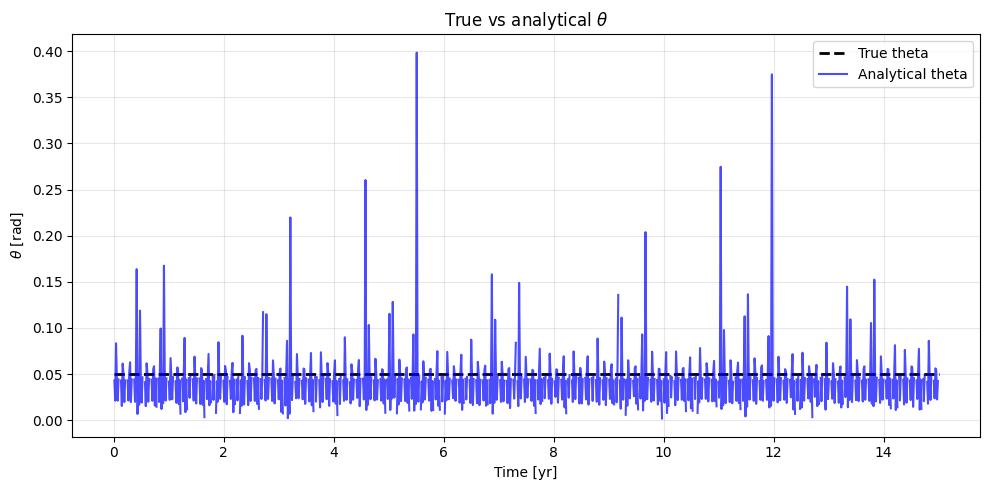

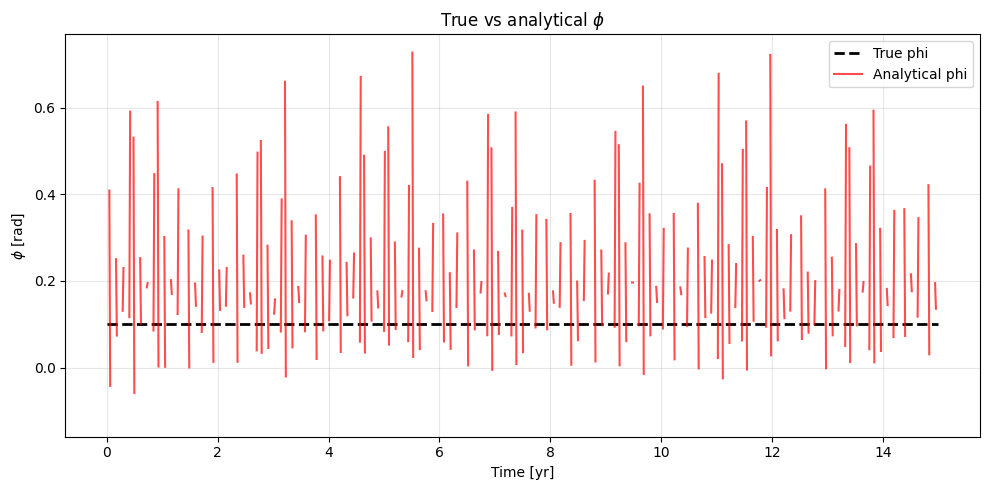

In [ ]:
# ========================================================
# Plot theta
# ========================================================
plt.figure(figsize=(10, 5))
plt.plot(t / YR, np.full_like(t, true_theta), "k--", lw=2, label="True theta")
plt.plot(t / YR, theta_analytic, "b-", alpha=0.7, label="Analytical theta")
plt.xlabel("Time [yr]")
plt.ylabel(r"$\theta$ [rad]")
plt.title(r"True vs analytical $\theta$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# ========================================================
# Plot phi
# ========================================================
plt.figure(figsize=(10, 5))
plt.plot(t / YR, np.full_like(t, true_phi),"k--", lw=2, label="True phi")
plt.plot(t / YR, phi_analytic, "r-", alpha=0.7,label="Analytical phi")
plt.xlabel("Time [yr]")
plt.ylabel(r"$\phi$ [rad]")
plt.title(r"True vs analytical $\phi$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

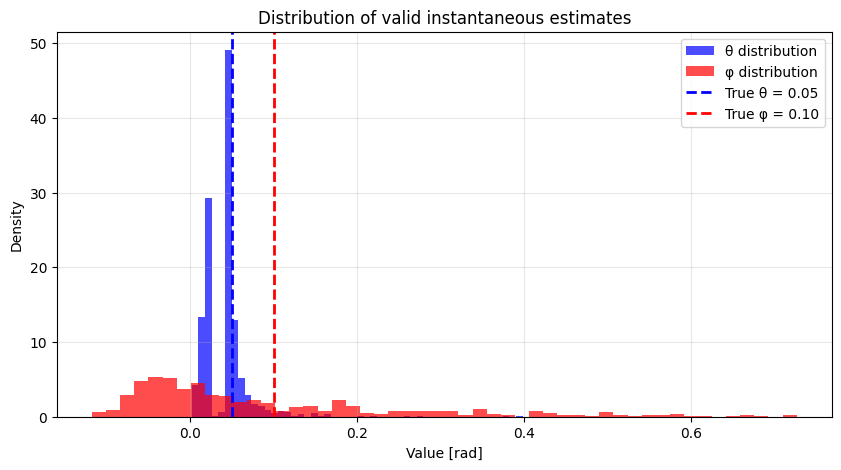

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(theta_analytic[valid_theta], bins=50, alpha=0.7, label='θ distribution', color='blue', density=True)
plt.hist(phi_analytic[valid_phi],   bins=50, alpha=0.7, label='φ distribution', color='red', density=True)
plt.axvline(true_theta, color='blue', linestyle='--', lw=2, label=f'True θ = {true_theta:.2f}')
plt.axvline(true_phi,   color='red',  linestyle='--', lw=2, label=f'True φ = {true_phi:.2f}')
plt.xlabel("Value [rad]")
plt.ylabel("Density")
plt.title("Distribution of valid instantaneous estimates")
plt.legend()
plt.grid(alpha=0.3)
plt.show()